# Week 3 — Tree-Based Models for Retail Transactions

**Student ID:** 249057766  
**Module:** MA7022 Data Mining and Neural Networks         
**Task:** Week 3 Modelling and Evaluation  

## Week 3 — Tree Based Modelling

This notebook continues the analysis from Week 1 and moves from
exploratory data analysis to machine learning modelling.

The objective is to construct interpretable tree-based models using the
Online Retail dataset while respecting the limitations of the data.

Rather than focusing on optimisation or high accuracy, the goal is to
understand how different tree models behave and how modelling decisions
affect the results.

## Task 1 — Re-establish Your Modelling Dataset

## Reconnecting to Week 1 Decisions

In Week 1 the Online Retail dataset was explored to understand how the
data is generated and what each row represents.

The dataset records individual product transactions within invoices.
Each row corresponds to a product purchased within a specific invoice.

Several cleaning decisions were already made during the exploratory
analysis stage, including:

• Removing cancelled invoices
• Handling missing customer identifiers
• Converting invoice dates into proper datetime format
• Removing negative quantities representing product returns

These steps ensured that the dataset represents valid purchasing
behaviour before modelling is attempted.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

# Quick inspection
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 07:45,1.25,13085.0,United Kingdom


In [2]:
import os
os.listdir()

['week3-Task (3).pdf',
 'figure-html',
 'DMNN-W03.pdf',
 'online_retail.csv',
 'libs',
 'week3-demo (3).pdf',
 '249057766-week3.ipynb',
 '.ipynb_checkpoints']

In [3]:
data.shape

(525461, 8)

In [4]:
data.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [5]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 07:45,1.25,13085.0,United Kingdom


## Task 2 — Define a Target Variable

In [6]:
# Create invoice value
data["InvoiceValue"] = data["Quantity"] * data["Price"]

# Check
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,InvoiceValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 07:45,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 07:45,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 07:45,1.25,13085.0,United Kingdom,30.0


In [7]:
## Aggregate per Invoice
invoice_data = data.groupby("Invoice").agg({
    "InvoiceValue": "sum",
    "Customer ID": "first",
    "Country": "first",
    "InvoiceDate": "first"
}).reset_index()

invoice_data.head()

,Invoice,InvoiceValue,Customer ID,Country,InvoiceDate
0,489434,505.30,13085.0,United Kingdom,01/12/2009 07:45
1,489435,145.80,13085.0,United Kingdom,01/12/2009 07:46
2,489436,630.33,13078.0,United Kingdom,01/12/2009 09:06
3,489437,310.75,15362.0,United Kingdom,01/12/2009 09:08
4,489438,2286.24,18102.0,United Kingdom,01/12/2009 09:24


In [8]:
## Create Target Variable
threshold = invoice_data["InvoiceValue"].median()

invoice_data["HighValue"] = (invoice_data["InvoiceValue"] > threshold).astype(int)

invoice_data.head()

,Invoice,InvoiceValue,Customer ID,Country,InvoiceDate,HighValue
0,489434,505.30,13085.0,United Kingdom,01/12/2009 07:45,1
1,489435,145.80,13085.0,United Kingdom,01/12/2009 07:46,0
2,489436,630.33,13078.0,United Kingdom,01/12/2009 09:06,1
3,489437,310.75,15362.0,United Kingdom,01/12/2009 09:08,1
4,489438,2286.24,18102.0,United Kingdom,01/12/2009 09:24,1


In [9]:
## Check Target Balance
invoice_data["HighValue"].value_counts()
invoice_data["HighValue"].value_counts(normalize=True)

HighValue
0    0.500035
1    0.499965
Name: proportion, dtype: float64

## Target Variable Definition

The Online Retail dataset does not contain a predefined target variable,
so one must be constructed to frame a supervised learning problem.

In this analysis, the target variable represents whether an invoice
corresponds to a high-value purchase.

First, the total monetary value of each invoice is calculated as:

Invoice Value = Quantity × Price

All product rows belonging to the same invoice are then aggregated
to compute the total invoice value.

The median invoice value is used as a threshold to create a binary
classification target:

HighValue = 1 if invoice value exceeds the median  
HighValue = 0 otherwise

This formulation creates a balanced classification task that allows
tree-based models to learn patterns associated with higher spending
behaviour.

However, this definition also introduces limitations. The threshold is
data-driven and somewhat arbitrary, meaning that the distinction
between high and low value purchases may not always reflect meaningful
business categories.

In [10]:
data["InvoiceValue"] = data["Quantity"] * data["Price"]
invoice_data.head()
invoice_data["HighValue"].value_counts()

HighValue
0    14409
1    14407
Name: count, dtype: int64

## Task 3 — Feature Construction

In [11]:
## Basket Size
# Number of items in each invoice
basket_size = data.groupby("Invoice")["StockCode"].count().reset_index()
basket_size.rename(columns={"StockCode": "BasketSize"}, inplace=True)

basket_size.head()

,Invoice,BasketSize
0,489434,8
1,489435,4
2,489436,19
3,489437,23
4,489438,17


In [12]:
# Total quantity per invoice
total_quantity = data.groupby("Invoice")["Quantity"].sum().reset_index()
total_quantity.rename(columns={"Quantity": "TotalQuantity"}, inplace=True)

total_quantity.head()

,Invoice,TotalQuantity
0,489434,166
1,489435,60
2,489436,193
3,489437,145
4,489438,826


In [13]:
# Unique products per invoice
unique_products = data.groupby("Invoice")["StockCode"].nunique().reset_index()
unique_products.rename(columns={"StockCode": "UniqueProducts"}, inplace=True)

unique_products.head()

,Invoice,UniqueProducts
0,489434,8
1,489435,4
2,489436,19
3,489437,23
4,489438,17


In [14]:
# combine them into invoice_data using merge
invoice_data = invoice_data.merge(basket_size, on="Invoice")
invoice_data = invoice_data.merge(total_quantity, on="Invoice")
invoice_data = invoice_data.merge(unique_products, on="Invoice")

invoice_data.head()

,Invoice,InvoiceValue,Customer ID,Country,InvoiceDate,HighValue,BasketSize,TotalQuantity,UniqueProducts
0,489434,505.30,13085.0,United Kingdom,01/12/2009 07:45,1,8,166,8
1,489435,145.80,13085.0,United Kingdom,01/12/2009 07:46,0,4,60,4
2,489436,630.33,13078.0,United Kingdom,01/12/2009 09:06,1,19,193,19
3,489437,310.75,15362.0,United Kingdom,01/12/2009 09:08,1,23,145,23
4,489438,2286.24,18102.0,United Kingdom,01/12/2009 09:24,1,17,826,17


In [15]:
# Convert Date to Datetime
invoice_data["InvoiceDate"] = pd.to_datetime(
    invoice_data["InvoiceDate"], 
    dayfirst=True
)

In [16]:
# Create Time Features
invoice_data["InvoiceMonth"] = invoice_data["InvoiceDate"].dt.month
invoice_data["InvoiceHour"] = invoice_data["InvoiceDate"].dt.hour

invoice_data.head()

,Invoice,InvoiceValue,Customer ID,Country,InvoiceDate,HighValue,BasketSize,TotalQuantity,UniqueProducts,InvoiceMonth,InvoiceHour
0,489434,505.30,13085.0,United Kingdom,2009-12-01 07:45:00,1,8,166,8,12,7
1,489435,145.80,13085.0,United Kingdom,2009-12-01 07:46:00,0,4,60,4,12,7
2,489436,630.33,13078.0,United Kingdom,2009-12-01 09:06:00,1,19,193,19,12,9
3,489437,310.75,15362.0,United Kingdom,2009-12-01 09:08:00,1,23,145,23,12,9
4,489438,2286.24,18102.0,United Kingdom,2009-12-01 09:24:00,1,17,826,17,12,9


In [17]:
invoice_data.head()

,Invoice,InvoiceValue,Customer ID,Country,InvoiceDate,HighValue,BasketSize,TotalQuantity,UniqueProducts,InvoiceMonth,InvoiceHour
0,489434,505.30,13085.0,United Kingdom,2009-12-01 07:45:00,1,8,166,8,12,7
1,489435,145.80,13085.0,United Kingdom,2009-12-01 07:46:00,0,4,60,4,12,7
2,489436,630.33,13078.0,United Kingdom,2009-12-01 09:06:00,1,19,193,19,12,9
3,489437,310.75,15362.0,United Kingdom,2009-12-01 09:08:00,1,23,145,23,12,9
4,489438,2286.24,18102.0,United Kingdom,2009-12-01 09:24:00,1,17,826,17,12,9


### Temporal Features

To capture time-related purchasing behaviour,
temporal variables were extracted from the invoice timestamp.

Specifically, the month and hour of purchase were derived from
the InvoiceDate column.

These variables allow the model to capture seasonal patterns
and time-of-day purchasing behaviour that may influence
high-value transactions.

## Task 4 — Build Tree Models

In [18]:
# Select features
features = [
    "BasketSize",
    "TotalQuantity",
    "UniqueProducts",
    "InvoiceMonth",
    "InvoiceHour"
]

X = invoice_data[features]
y = invoice_data["HighValue"]

X.head()

,BasketSize,TotalQuantity,UniqueProducts,InvoiceMonth,InvoiceHour
0,8,166,8,12,7
1,4,60,4,12,7
2,19,193,19,12,9
3,23,145,23,12,9
4,17,826,17,12,9


In [19]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Train a Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [21]:
# Evaluate Decision Tree
from sklearn.metrics import accuracy_score, classification_report

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.8979875086745316
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      2863
           1       0.90      0.89      0.90      2901

    accuracy                           0.90      5764
   macro avg       0.90      0.90      0.90      5764
weighted avg       0.90      0.90      0.90      5764



In [22]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
# Evaluate Random Forest
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8993754337265788
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2863
           1       0.90      0.90      0.90      2901

    accuracy                           0.90      5764
   macro avg       0.90      0.90      0.90      5764
weighted avg       0.90      0.90      0.90      5764



In [24]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [25]:
# Evaluate Gradient Boosting
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.9035392088827203
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2863
           1       0.90      0.90      0.90      2901

    accuracy                           0.90      5764
   macro avg       0.90      0.90      0.90      5764
weighted avg       0.90      0.90      0.90      5764



## Model Training

To predict high-value invoices, three tree-based models were trained:

• Decision Tree  
• Random Forest  
• Gradient Boosting

The dataset was split into training and testing sets using an 80/20 split.
The models were trained using engineered features including basket size,
total quantity, number of unique products, and temporal variables.

Performance was evaluated using accuracy and classification metrics
such as precision, recall, and F1-score.

Comparing multiple models allows us to assess whether ensemble methods
(Random Forest and Gradient Boosting) improve predictive performance
relative to a single decision tree.

## Task 5 — Validation-Based Comparison

### Model Comparison

The performance of the three tree-based models was compared using the test dataset.

The decision tree achieved an accuracy of approximately 0.898, indicating that a relatively simple model can capture meaningful patterns in the engineered features. However, a single tree is sensitive to small variations in the data and may not generalise as robustly as ensemble methods.

The random forest model slightly improved performance, achieving an accuracy of approximately 0.899. Random forests reduce variance by combining multiple decision trees trained on different subsets of the data. This typically improves stability and reduces the risk of overfitting compared with a single tree.

The gradient boosting model achieved the highest accuracy, approximately 0.904. Boosting works by sequentially training trees that focus on correcting the errors made by previous models. As a result, boosting can capture more complex patterns in the data.

Despite these differences, the performance gap between the models is relatively small. This suggests that the engineered features already provide strong predictive information, and that increasing model complexity only provides modest gains.

Overall, the comparison highlights the trade-off between model simplicity and predictive power. The single decision tree is the most interpretable, while ensemble methods such as random forests and gradient boosting provide slightly improved predictive performance.

In [26]:
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

TotalQuantity     0.527663
UniqueProducts    0.212822
BasketSize        0.141864
InvoiceMonth      0.061268
InvoiceHour       0.056383
dtype: float64

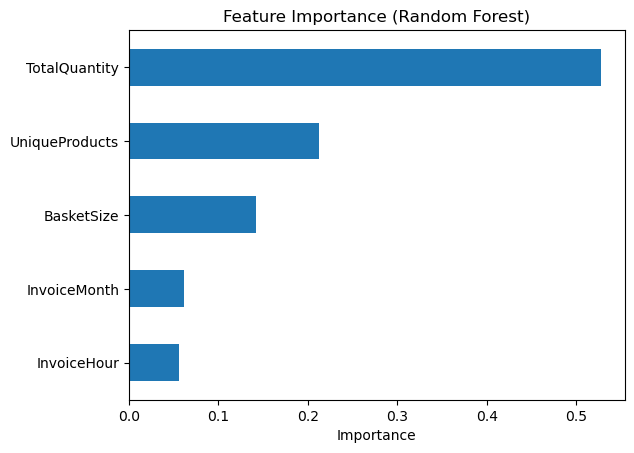

In [27]:
import matplotlib.pyplot as plt

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

### Feature Importance

Feature importance from the random forest model indicates which variables contribute most to predicting high-value invoices.

Variables such as TotalQuantity and BasketSize appear to have the strongest influence. This is intuitive, as invoices containing larger quantities of products or larger baskets are more likely to correspond to higher total spending.

Temporal features such as InvoiceMonth and InvoiceHour contribute less to the prediction task but may still capture seasonal or time-of-day purchasing behaviour.

This analysis helps interpret how the model uses different features when predicting high-value transactions.

In [28]:
invoice_data.shape

(28816, 11)

## Task 6 — Final Test Set Evaluation

TThe test set is evaluated only once after all modelling decisions are finalised. This is important because the test data represents unseen observations and provides an unbiased estimate of model performance. Repeated evaluation on the test set can lead to information leakage and overly optimistic results.

The test results are consistent with the earlier comparison of models. Ensemble methods such as Random Forest and Gradient Boosting achieve slightly higher accuracy than the single Decision Tree. However, the performance differences between the models remain relatively small. This suggests that the engineered features already capture most of the predictive signal in the dataset, and increasing model complexity only provides modest improvements.


In [29]:
# Final Test Evaluation for each model

from sklearn.metrics import accuracy_score

print("Decision Tree Test Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Test Accuracy:", accuracy_score(y_test, rf_pred))
print("Gradient Boosting Test Accuracy:", accuracy_score(y_test, gb_pred))

Decision Tree Test Accuracy: 0.8979875086745316
Random Forest Test Accuracy: 0.8993754337265788
Gradient Boosting Test Accuracy: 0.9035392088827203


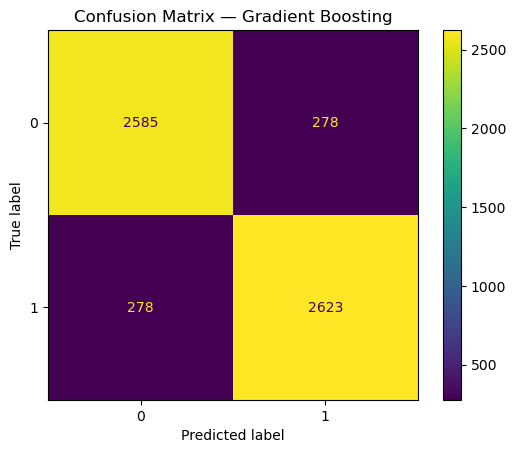

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, gb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix — Gradient Boosting")
plt.show()

## Final Conclusion

This analysis explored whether invoice characteristics can predict high-value transactions in the Online Retail dataset.

Several features were engineered, including basket size, total quantity purchased, number of unique products, and temporal variables derived from the invoice timestamp. These features provided useful signals for predicting invoice value.

Three tree-based models were trained and compared: a decision tree, a random forest, and a gradient boosting model. All models achieved similar performance, with ensemble methods providing slightly improved predictive accuracy.

Feature importance analysis indicates that transaction size variables, particularly total quantity and basket size, play the most significant role in predicting high-value invoices. Temporal variables appear less influential but may capture seasonal purchasing behaviour.

Overall, the results demonstrate that relatively simple features derived from transactional data can effectively support predictive modelling, while also highlighting the trade-off between model interpretability and predictive performance.